In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RetailIQ Product & Sales Analysis started!")

RetailIQ Product & Sales Analysis started!


In [2]:
# ===== LOAD CLEANED DATA =====

file_path = "../data/processed/clean_sales_data.csv"

sales_df = pd.read_csv(file_path)

sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

print("Clean sales dataset loaded successfully!")
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))

Clean sales dataset loaded successfully!
Rows: 392692
Columns: 9


In [3]:
# ===== TOP 10 PRODUCTS BY REVENUE =====

top_products = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

,Description,Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


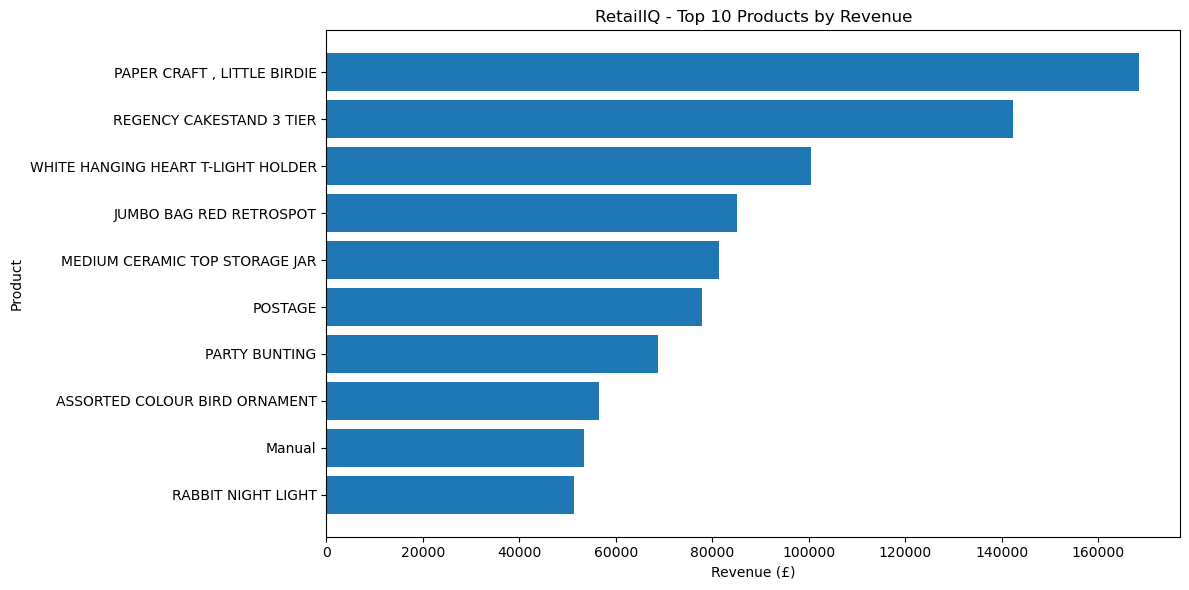

In [4]:
# ===== TOP 10 PRODUCTS REVENUE =====

plt.figure(figsize=(12, 6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("RetailIQ - Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
# ===== TOP 10 PRODUCTS BY QUANTITY =====

top_quantity_products = (
    sales_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_quantity_products)

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3,JUMBO BAG RED RETROSPOT,46078
4,WHITE HANGING HEART T-LIGHT HOLDER,36706
5,ASSORTED COLOUR BIRD ORNAMENT,35263
6,PACK OF 72 RETROSPOT CAKE CASES,33670
7,POPCORN HOLDER,30919
8,RABBIT NIGHT LIGHT,27153
9,MINI PAINT SET VINTAGE,26076


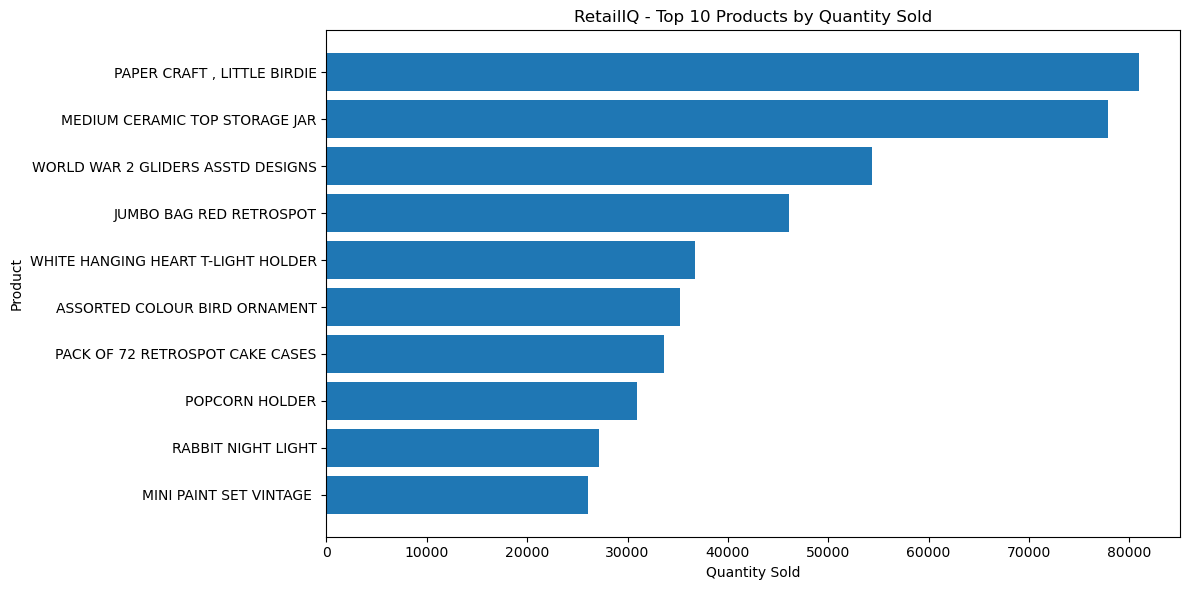

In [6]:
# ===== TOP 10 PRODUCTS BY QUANTITY CHART =====

plt.figure(figsize=(12, 6))

plt.barh(
    top_quantity_products["Description"],
    top_quantity_products["Quantity"]
)

plt.title("RetailIQ - Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [7]:
# ===== COUNTRY-WISE REVENUE =====

country_sales = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(country_sales.head(15))

,Country,Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


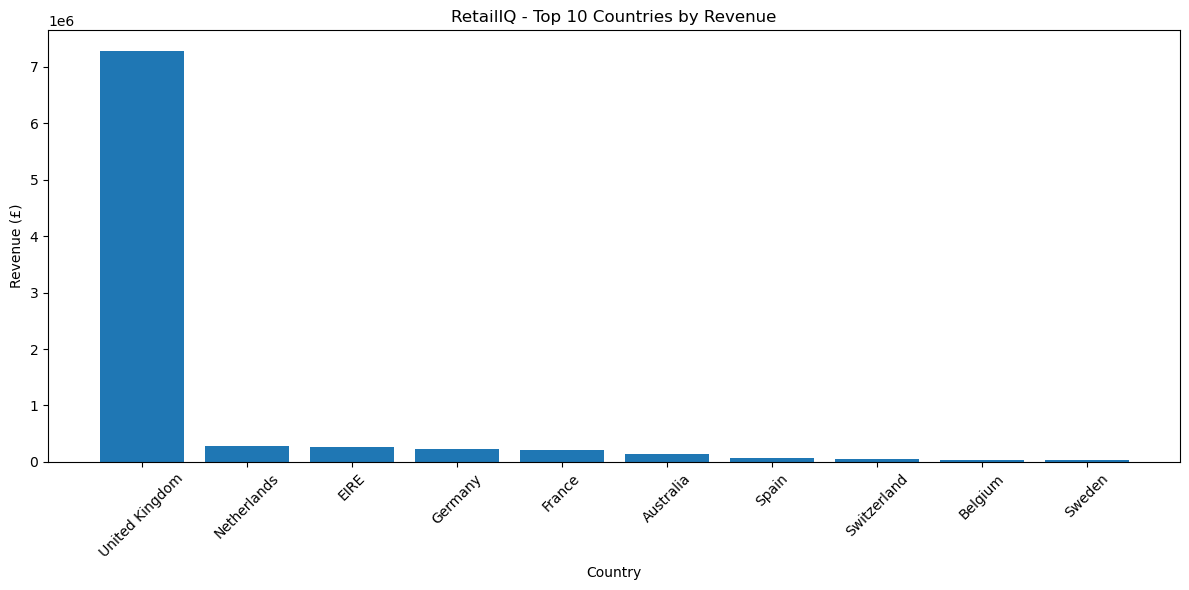

In [8]:
# ===== TOP 10 COUNTRIES BY REVENUE =====

top_countries = country_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("RetailIQ - Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# ===== PRODUCT REVENUE CONTRIBUTION =====

total_revenue = sales_df["Revenue"].sum()

top_products["Revenue_Percentage"] = (
    top_products["Revenue"] / total_revenue * 100
)

display(top_products)

,Description,Revenue,Revenue_Percentage
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.895641
1,REGENCY CAKESTAND 3 TIER,142264.75,1.600781
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,1.129625
3,JUMBO BAG RED RETROSPOT,85040.54,0.956887
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.916111
5,POSTAGE,77803.96,0.875460
6,PARTY BUNTING,68785.23,0.773980
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03,0.634767
8,Manual,53419.93,0.601088
9,RABBIT NIGHT LIGHT,51251.24,0.576685


In [10]:
# ===== PRODUCT PERFORMANCE ANALYSIS =====

product_performance = (
    sales_df
    .groupby("Description")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        NumberOfOrders=("InvoiceNo", "nunique"),
        AveragePrice=("UnitPrice", "mean")
    )
    .sort_values("TotalRevenue", ascending=False)
    .reset_index()
)

display(product_performance.head(20))

,Description,TotalRevenue,TotalQuantity,NumberOfOrders,AveragePrice
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
1,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703,12.482896
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971,2.892768
3,JUMBO BAG RED RETROSPOT,85040.54,46078,1600,2.015969
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,1.220303
5,POSTAGE,77803.96,3120,1099,31.570482
6,PARTY BUNTING,68785.23,15279,1379,4.876220
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375,1.680710
8,Manual,53419.93,6933,253,178.406129
9,RABBIT NIGHT LIGHT,51251.24,27153,801,2.012770


In [11]:
# ===== BEST SELLING PRODUCT =====

best_selling_product = (
    product_performance
    .sort_values("TotalQuantity", ascending=False)
    .head(1)
)

display(best_selling_product)

,Description,TotalRevenue,TotalQuantity,NumberOfOrders,AveragePrice
0,"PAPER CRAFT , LITTLE BIRDIE",168469.6,80995,1,2.08


In [12]:
# ===== BEST SELLING PRODUCT =====

best_selling_product = (
    product_performance
    .sort_values("TotalQuantity", ascending=False)
    .head(1)
)

display(best_selling_product)

,Description,TotalRevenue,TotalQuantity,NumberOfOrders,AveragePrice
0,"PAPER CRAFT , LITTLE BIRDIE",168469.6,80995,1,2.08


In [13]:
# ===== COUNTRY PERFORMANCE =====

country_performance = (
    sales_df
    .groupby("Country")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalCustomers=("CustomerID", "nunique"),
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
    .reset_index()
)

display(country_performance.head(15))

,Country,TotalRevenue,TotalOrders,TotalCustomers,TotalQuantity
0,United Kingdom,7285024.644,16646,3920,4241305
1,Netherlands,285446.340,94,9,200361
2,EIRE,265262.460,260,3,140133
3,Germany,228678.400,457,94,119154
4,France,208934.310,389,87,111428
5,Australia,138453.810,57,9,83891
6,Spain,61558.560,90,30,27933
7,Switzerland,56443.950,51,21,30082
8,Belgium,41196.340,98,25,23237
9,Sweden,38367.830,36,8,36078


In [14]:
# ===== SAVE PRODUCT AND COUNTRY ANALYSIS =====

product_performance.to_csv(
    "../data/processed/product_performance.csv",
    index=False
)

country_performance.to_csv(
    "../data/processed/country_performance.csv",
    index=False
)

print("Product and country analysis saved successfully!")

Product and country analysis saved successfully!
